This notebook trains a random forest model to predict the binning label of each image based on the features extracted from the cell profiling pipeline. 
The model is trained on a balanced dataset, where each binning label is represented equally. 
The dataset is split into training, validation, and test sets, and the model's performance is evaluated on the test set.
The predicted bins are used to adjust the segmentation parameters for each image, which is expected to improve the segmentation quality.

In [1]:
import argparse
import json
import os
import pathlib
import sys
import time

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
import tifffile
import torch
from arg_parsing_utils import check_for_missing_args, parse_args
from cellpose import models
from file_reading import *
from file_reading import read_zstack_image
from notebook_init_utils import bandicoot_check, init_notebook
from skimage.filters import sobel
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
def read_labels(infile: str) -> dict:
    """
    Description
    ----------
    Read labels from a parquet file.
    Parameters
    ----------
    infile : str
        Path to the input parquet file.
    Returns
    -------
    dict
        Dictionary containing the labels.
    """
    data = pd.read_parquet(infile).to_dict(orient="list")
    return data

In [3]:
start_time = time.time()
# get starting memory (cpu)
start_mem = psutil.Process(os.getpid()).memory_info().rss / 1024**2

In [4]:
root_dir, in_notebook = init_notebook()

image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot/NF1_organoid_data")).resolve(),
    root_dir,
)
patient_list_file_path = pathlib.Path(f"{root_dir}/data/patient_IDs.txt").resolve(
    strict=True
)
raw_image_base_dir = pathlib.Path(f"{image_base_dir}/data/").resolve()

In [5]:
labels_save_file = pathlib.Path(
    "../image_labels/organoid_image_labels.parquet"
).resolve(strict=True)
all_features_save_path = pathlib.Path(
    f"../../3.cellprofiling/results/all_features.parquet"
).resolve(strict=True)
labels = read_labels(labels_save_file)
labels_df = pd.DataFrame(labels)
labels_df
all_features_df = pd.read_parquet(all_features_save_path)
all_features_df
df = pd.merge(
    all_features_df,
    labels_df,
    on=["patient", "well_fov"],
    how="right",
)
# drop rows with na
df = df.dropna(subset=["label"])

In [6]:
# down sample the training group to be class balanced
class_counts = df["label"].value_counts()
min_count = class_counts.min()

df = (
    df.groupby("label", group_keys=True)
    .apply(lambda x: x.sample(n=min_count, random_state=0))
    .reset_index()
)

df["label"].value_counts()

label
elongated            58
globular             58
small/dissociated    58
Name: count, dtype: int64

In [7]:
# set up data splits
# train: 80%, val: 10%, test: 10%
# stratify by label, patient

train_df, test_df = train_test_split(
    df,
    test_size=0.10,
    random_state=0,
    stratify=df[["label", "patient"]],
)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.1111,  # 0.1111 * 0.90 = 0.10 (10% test)
    random_state=0,
    stratify=train_df[["label", "patient"]],
)
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 138
Validation size: 18
Test size: 18


In [8]:
# train a multi-class logistic regression model for the organoid labels
from sklearn.linear_model import LogisticRegression

rf_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
)

rf_model.fit(
    train_df.drop(columns=["patient", "well_fov", "label", "annotator"]),
    train_df["label"],
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
train_preds = rf_model.predict(
    train_df.drop(columns=["patient", "well_fov", "label", "annotator"])
)
print("Train Classification Report:")
print(classification_report(train_df["label"], train_preds))
print("Train Confusion Matrix:")
print(confusion_matrix(train_df["label"], train_preds))
val_preds = rf_model.predict(
    val_df.drop(columns=["patient", "well_fov", "label", "annotator"])
)
print("Validation Classification Report:")
print(classification_report(val_df["label"], val_preds))
print("Validation Confusion Matrix:")
print(confusion_matrix(val_df["label"], val_preds))
test_preds = rf_model.predict(
    test_df.drop(columns=["patient", "well_fov", "label", "annotator"])
)
print("Test Classification Report:")
print(classification_report(test_df["label"], test_preds))
print("Test Confusion Matrix:")
print(confusion_matrix(test_df["label"], test_preds))

Train Classification Report:
                   precision    recall  f1-score   support

        elongated       1.00      1.00      1.00        46
         globular       1.00      1.00      1.00        47
small/dissociated       1.00      1.00      1.00        45

         accuracy                           1.00       138
        macro avg       1.00      1.00      1.00       138
     weighted avg       1.00      1.00      1.00       138

Train Confusion Matrix:
[[46  0  0]
 [ 0 47  0]
 [ 0  0 45]]
Validation Classification Report:
                   precision    recall  f1-score   support

        elongated       0.57      0.80      0.67         5
         globular       0.75      1.00      0.86         6
small/dissociated       0.67      0.29      0.40         7

         accuracy                           0.67        18
        macro avg       0.66      0.70      0.64        18
     weighted avg       0.67      0.67      0.63        18

Validation Confusion Matrix:
[[4 0 1]
 [0 6 

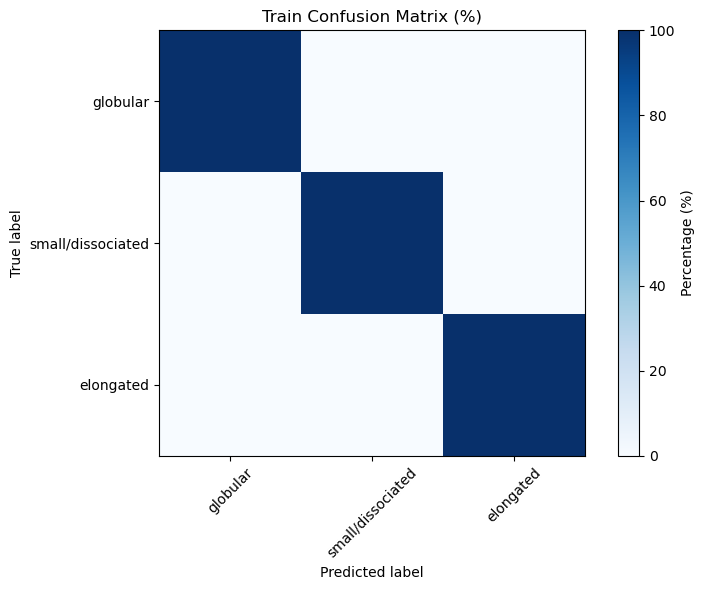

In [10]:
# plot the confusion matrix for the test set (row-normalized to percentages)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(train_df["label"], train_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Train Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")

tick_marks = np.arange(3)
plt.xticks(tick_marks, ["globular", "small/dissociated", "elongated"], rotation=45)
plt.yticks(tick_marks, ["globular", "small/dissociated", "elongated"])
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

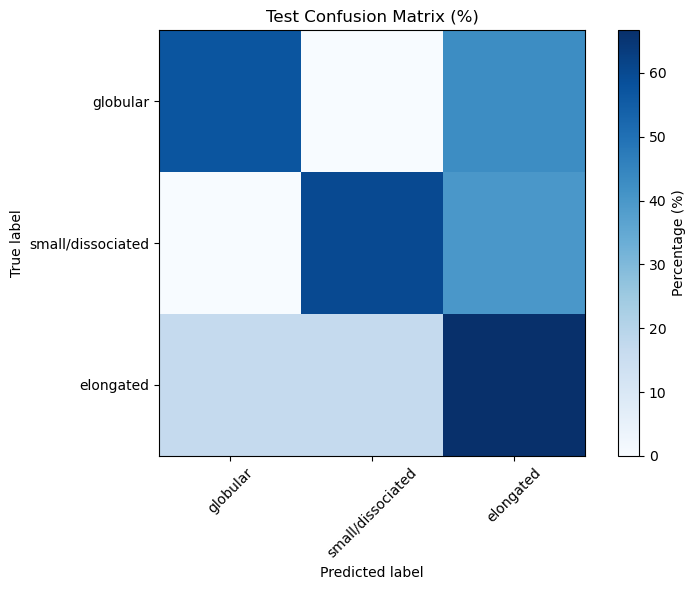

In [11]:
# plot the confusion matrix for the test set (row-normalized to percentages)
plt.figure(figsize=(8, 6))
cm = confusion_matrix(test_df["label"], test_preds)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

im = plt.imshow(cm_pct, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Test Confusion Matrix (%)")
cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")

tick_marks = np.arange(3)
plt.xticks(tick_marks, ["globular", "small/dissociated", "elongated"], rotation=45)
plt.yticks(tick_marks, ["globular", "small/dissociated", "elongated"])
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

In [12]:
# concatenate the train, val, test df with the predections
train_preds = rf_model.predict(
    train_df.drop(columns=["patient", "well_fov", "label", "annotator"])
)

train_out = train_df.assign(split="train", prediction=train_preds)
val_out = val_df.assign(split="val", prediction=val_preds)
test_out = test_df.assign(split="test", prediction=test_preds)

all_preds_df = pd.concat([train_out, val_out, test_out], ignore_index=True)
all_preds_df["image_path"] = all_preds_df.apply(
    lambda row: pathlib.Path(
        f"{raw_image_base_dir}/{row['patient']}/zstack_images/"
        f"{row['well_fov']}/{row['well_fov']}_555.tif"
    ).resolve(),
    axis=1,
)
all_preds_df.head()

,label,level_1,patient,well_fov,405_CHAMI75_feature_0,405_CHAMI75_feature_1,405_CHAMI75_feature_10,405_CHAMI75_feature_100,405_CHAMI75_feature_101,405_CHAMI75_feature_102,...,TRANS_SAMMed3D_feature_94,TRANS_SAMMed3D_feature_95,TRANS_SAMMed3D_feature_96,TRANS_SAMMed3D_feature_97,TRANS_SAMMed3D_feature_98,TRANS_SAMMed3D_feature_99,annotator,split,prediction,image_path
0,globular,362,NF0030_T1,E10-2,-2.035447,-1.826033,1.893233,-1.491394,5.392480,2.116595,...,0.002403,-0.081989,0.054081,0.174138,0.442238,0.125255,Mike,train,globular,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
1,elongated,254,NF0014_T2,E2-2,0.010298,-0.572013,1.283431,-0.345900,1.093875,5.496044,...,0.005109,-0.093104,0.038358,0.143606,0.448821,0.085199,Mike,train,elongated,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
2,small/dissociated,684,NF0016_T1,D2-2,0.541687,-1.157941,6.151188,1.440018,5.832963,6.341245,...,0.003675,-0.085886,0.049997,0.140195,0.447945,0.095300,Mike,train,small/dissociated,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
3,globular,1277,NF0021_T1,G8-2,4.839879,-2.408165,4.866729,2.918861,4.089725,3.457253,...,0.016330,-0.053569,0.070934,0.219427,0.427848,0.159316,Mike,train,globular,/home/lippincm/mnt/bandicoot/NF1_organoid_data...
4,elongated,203,NF0014_T2,D4-7,0.584323,-3.479404,0.376639,-0.928312,5.334506,2.829546,...,0.005160,-0.076898,0.042550,0.145553,0.455588,0.089165,Mike,train,elongated,/home/lippincm/mnt/bandicoot/NF1_organoid_data...


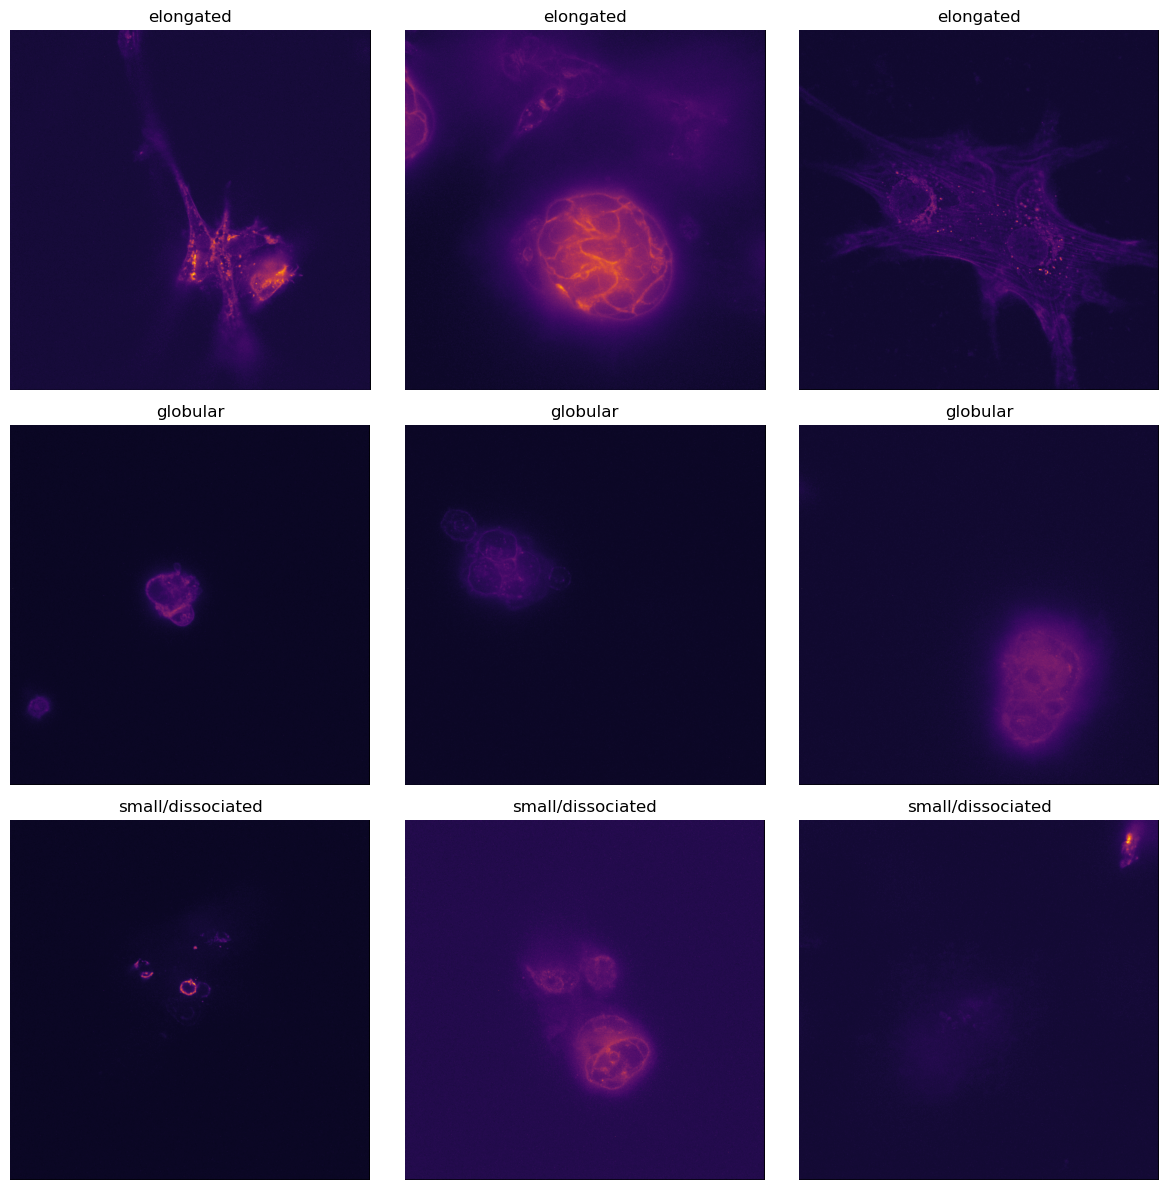

In [13]:
# pick three random images from each predicted class to show
label_names = {0: "globular", 1: "small/dissociated", 2: "elongated"}
rng = np.random.default_rng(0)
samples_per_class = 3

sampled_rows = []
for pred_label, group in all_preds_df.groupby("prediction"):
    n = min(samples_per_class, len(group))
    sampled_rows.append(group.sample(n=n, random_state=rng.integers(0, 1_000_000)))

sampled_df = pd.concat(sampled_rows, ignore_index=True)

n_classes = len(sampled_df["prediction"].unique())
fig, axes = plt.subplots(
    n_classes, samples_per_class, figsize=(4 * samples_per_class, 4 * n_classes)
)
if n_classes == 1:
    axes = np.array([axes])

for row_idx, (pred_label, group) in enumerate(sampled_df.groupby("prediction")):
    group = group.reset_index(drop=True)
    for col_idx in range(samples_per_class):
        ax = axes[row_idx, col_idx]
        if col_idx >= len(group):
            ax.axis("off")
            continue
        image_path = group.loc[col_idx, "image_path"]
        img = read_zstack_image(image_path)
        mid = img[img.shape[0] // 2]
        ax.imshow(mid, cmap="inferno")
        ax.axis("off")
        title = label_names.get(pred_label, str(pred_label))
        ax.set_title(title)

plt.tight_layout()
plt.show()